In [ ]:
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import os

dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=False, download=True,
    transform=transforms.ToTensor()
)

os.makedirs("emnist_samples", exist_ok=True)

for i in range(20):
    img_tensor, label = dataset[i]
    img = transforms.ToPILImage()(img_tensor)
    img = img.resize((64, 64))
    img.save(f"emnist_samples/sample_{i}_label_{chr(64+label)}.png")

print("20 images saved to emnist_samples/")

from google.colab import files
import zipfile

with zipfile.ZipFile("emnist_samples.zip", "w") as z:
    for f in os.listdir("emnist_samples"):
        z.write(f"emnist_samples/{f}")

files.download("emnist_samples.zip")

100%|██████████| 562M/562M [00:02<00:00, 198MB/s]


20 images saved to emnist_samples/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# FSDL Lab 6 | Data Annotation & Dataset Preprocessing
# Annotated 20 EMNIST letter images using Label Studio
# Parsing real annotation export and building a PyTorch Dataset from it

import json
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
from collections import Counter

print("Setup complete.")

Setup complete.


In [ ]:
# paste your actual annotation JSON here
annotations_json = '[{"id":2,"annotations":[{"id":2,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"tsqghcnjzU","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:28:26.306117Z","updated_at":"2026-03-01T19:28:26.306133Z","draft_created_at":null,"lead_time":5.794,"prediction":{},"result_count":1,"unique_id":"40b50275-c0ea-417f-b664-5c2ea35d19e6","import_id":null,"last_action":null,"bulk_created":false,"task":2,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"3d2a0436-sample_1_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/3d2a0436-sample_1_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702075Z","updated_at":"2026-03-01T19:28:26.370071Z","allow_skip":true,"inner_id":2,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":3,"annotations":[{"id":3,"completed_by":1,"result":[{"value":{"choices":["D"]},"id":"31RqrD72SF","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:02.369232Z","updated_at":"2026-03-01T19:58:02.369249Z","draft_created_at":null,"lead_time":3.134,"prediction":{},"result_count":1,"unique_id":"fc5651f2-38fc-4a57-936f-d394e1c0d289","import_id":null,"last_action":null,"bulk_created":false,"task":3,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"aa9ac652-sample_2_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/aa9ac652-sample_2_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702129Z","updated_at":"2026-03-01T19:58:02.424939Z","allow_skip":true,"inner_id":3,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":4,"annotations":[{"id":4,"completed_by":1,"result":[{"value":{"choices":["F"]},"id":"0STpTx6lMB","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:05.717087Z","updated_at":"2026-03-01T19:58:05.717103Z","draft_created_at":null,"lead_time":2.295,"prediction":{},"result_count":1,"unique_id":"b60409d7-0bd6-411c-beaa-ad03d4cc951d","import_id":null,"last_action":null,"bulk_created":false,"task":4,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"7f49cf12-sample_3_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/7f49cf12-sample_3_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702179Z","updated_at":"2026-03-01T19:58:05.774481Z","allow_skip":true,"inner_id":4,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":5,"annotations":[{"id":5,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"e6eLsW9AsD","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:09.831400Z","updated_at":"2026-03-01T19:58:09.831415Z","draft_created_at":null,"lead_time":2.407,"prediction":{},"result_count":1,"unique_id":"30efac5b-c5c1-499f-bf99-f1cb13c3943f","import_id":null,"last_action":null,"bulk_created":false,"task":5,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"8375273b-sample_4_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/8375273b-sample_4_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702229Z","updated_at":"2026-03-01T19:58:09.887616Z","allow_skip":true,"inner_id":5,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":6,"annotations":[{"id":6,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"APP6rXuT3Y","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:13.051002Z","updated_at":"2026-03-01T19:58:13.051020Z","draft_created_at":null,"lead_time":2.167,"prediction":{},"result_count":1,"unique_id":"aff3fa30-40bb-4d52-8598-ac1f46756178","import_id":null,"last_action":null,"bulk_created":false,"task":6,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"28336534-sample_5_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/28336534-sample_5_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702270Z","updated_at":"2026-03-01T19:58:13.110759Z","allow_skip":true,"inner_id":6,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":7,"annotations":[{"id":7,"completed_by":1,"result":[{"value":{"choices":["G"]},"id":"IVwIV-zGWR","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:20.763535Z","updated_at":"2026-03-01T19:58:20.763553Z","draft_created_at":null,"lead_time":5.869,"prediction":{},"result_count":1,"unique_id":"ade9f038-0368-4e09-a186-33b777c29561","import_id":null,"last_action":null,"bulk_created":false,"task":7,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"6d3b93cd-sample_6_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/6d3b93cd-sample_6_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702323Z","updated_at":"2026-03-01T19:58:20.826025Z","allow_skip":true,"inner_id":7,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":8,"annotations":[{"id":8,"completed_by":1,"result":[{"value":{"choices":["F"]},"id":"b8j5Bvd5_T","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:27.449776Z","updated_at":"2026-03-01T19:58:27.449792Z","draft_created_at":null,"lead_time":5.141,"prediction":{},"result_count":1,"unique_id":"d23f87eb-6d86-47ab-aa79-ab3ac6be3611","import_id":null,"last_action":null,"bulk_created":false,"task":8,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"4ebe3e67-sample_7_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/4ebe3e67-sample_7_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702371Z","updated_at":"2026-03-01T19:58:27.508090Z","allow_skip":true,"inner_id":8,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":9,"annotations":[{"id":9,"completed_by":1,"result":[{"value":{"choices":["C"]},"id":"d7Hb3KVvtZ","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:35.079293Z","updated_at":"2026-03-01T19:58:35.079310Z","draft_created_at":null,"lead_time":2.383,"prediction":{},"result_count":1,"unique_id":"e768c112-f70f-42e2-ba48-d04d7e64e732","import_id":null,"last_action":null,"bulk_created":false,"task":9,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"5b7e5cef-sample_8_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/5b7e5cef-sample_8_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702412Z","updated_at":"2026-03-01T19:58:35.137406Z","allow_skip":true,"inner_id":9,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":10,"annotations":[{"id":10,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"Nl_-YAxTP1","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:38.451897Z","updated_at":"2026-03-01T19:58:38.451912Z","draft_created_at":null,"lead_time":2.323,"prediction":{},"result_count":1,"unique_id":"401351ab-f8b2-41ec-9e18-3fdb9d0e9205","import_id":null,"last_action":null,"bulk_created":false,"task":10,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"ec193b6e-sample_9_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/ec193b6e-sample_9_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702453Z","updated_at":"2026-03-01T19:58:38.517181Z","allow_skip":true,"inner_id":10,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":11,"annotations":[{"id":11,"completed_by":1,"result":[],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:41.884873Z","updated_at":"2026-03-01T19:58:41.884889Z","draft_created_at":null,"lead_time":2.415,"prediction":{},"result_count":0,"unique_id":"94f8c82f-9285-4542-a36b-3abee654b719","import_id":null,"last_action":null,"bulk_created":false,"task":11,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"734ab535-sample_10_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/734ab535-sample_10_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702493Z","updated_at":"2026-03-01T19:58:41.941384Z","allow_skip":true,"inner_id":11,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":12,"annotations":[{"id":12,"completed_by":1,"result":[{"value":{"choices":["B"]},"id":"8dCGldN9GP","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:45.443730Z","updated_at":"2026-03-01T19:58:45.443746Z","draft_created_at":null,"lead_time":2.309,"prediction":{},"result_count":1,"unique_id":"60f723b4-5080-4696-9668-0f545988cc07","import_id":null,"last_action":null,"bulk_created":false,"task":12,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"2f331e11-sample_11_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/2f331e11-sample_11_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702533Z","updated_at":"2026-03-01T19:58:45.507786Z","allow_skip":true,"inner_id":12,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":13,"annotations":[{"id":13,"completed_by":1,"result":[{"value":{"choices":["D"]},"id":"ATaoqm0Dvn","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:49.490621Z","updated_at":"2026-03-01T19:58:49.490636Z","draft_created_at":null,"lead_time":2.661,"prediction":{},"result_count":1,"unique_id":"378dc410-bd2f-4d20-aa74-74b99013b7e3","import_id":null,"last_action":null,"bulk_created":false,"task":13,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"1f20f849-sample_12_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/1f20f849-sample_12_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702573Z","updated_at":"2026-03-01T19:58:49.549142Z","allow_skip":true,"inner_id":13,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":14,"annotations":[{"id":14,"completed_by":1,"result":[{"value":{"choices":["F"]},"id":"bzsebj8SUb","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:52.672780Z","updated_at":"2026-03-01T19:58:52.672795Z","draft_created_at":null,"lead_time":2.043,"prediction":{},"result_count":1,"unique_id":"4ffa20a0-dcdb-4f98-a178-72a6f1977614","import_id":null,"last_action":null,"bulk_created":false,"task":14,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"1824171c-sample_13_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/1824171c-sample_13_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702615Z","updated_at":"2026-03-01T19:58:52.732375Z","allow_skip":true,"inner_id":14,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":15,"annotations":[{"id":15,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"eTl1ax7RyN","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:56.627203Z","updated_at":"2026-03-01T19:58:56.627218Z","draft_created_at":null,"lead_time":2.249,"prediction":{},"result_count":1,"unique_id":"5de8e257-48bf-4ee1-8151-816b051f3b8c","import_id":null,"last_action":null,"bulk_created":false,"task":15,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"30b9180b-sample_14_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/30b9180b-sample_14_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702659Z","updated_at":"2026-03-01T19:58:56.688649Z","allow_skip":true,"inner_id":15,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":16,"annotations":[{"id":16,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"hMN__FhLp5","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:58:59.813943Z","updated_at":"2026-03-01T19:58:59.813958Z","draft_created_at":null,"lead_time":2.3,"prediction":{},"result_count":1,"unique_id":"26ef2247-5635-4af9-8fac-365873ffd46b","import_id":null,"last_action":null,"bulk_created":false,"task":16,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"fdbe1da7-sample_15_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/fdbe1da7-sample_15_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702709Z","updated_at":"2026-03-01T19:58:59.876193Z","allow_skip":true,"inner_id":16,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":17,"annotations":[{"id":17,"completed_by":1,"result":[{"value":{"choices":["G"]},"id":"NkcmJZ-8Hw","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:59:11.215554Z","updated_at":"2026-03-01T19:59:11.215571Z","draft_created_at":"2026-03-01T19:59:10.873933Z","lead_time":6.893,"prediction":{},"result_count":1,"unique_id":"07cde043-7179-479c-9df5-9f7b3edc8923","import_id":null,"last_action":null,"bulk_created":false,"task":17,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"84ce45ea-sample_16_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/84ce45ea-sample_16_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702760Z","updated_at":"2026-03-01T19:59:11.277912Z","allow_skip":true,"inner_id":17,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":18,"annotations":[{"id":18,"completed_by":1,"result":[{"value":{"choices":["D"]},"id":"EtTcybRYEn","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:59:14.747778Z","updated_at":"2026-03-01T19:59:14.747796Z","draft_created_at":null,"lead_time":2.409,"prediction":{},"result_count":1,"unique_id":"63cecc4d-52ce-4b33-985e-337df9e2e3f5","import_id":null,"last_action":null,"bulk_created":false,"task":18,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"1434af04-sample_17_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/1434af04-sample_17_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702831Z","updated_at":"2026-03-01T19:59:14.808477Z","allow_skip":true,"inner_id":18,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":19,"annotations":[{"id":19,"completed_by":1,"result":[{"value":{"choices":["E"]},"id":"GH_xathfCF","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:59:19.409800Z","updated_at":"2026-03-01T19:59:19.409818Z","draft_created_at":null,"lead_time":2.846,"prediction":{},"result_count":1,"unique_id":"f678800a-46b6-41dc-921f-5d66324ee3f8","import_id":null,"last_action":null,"bulk_created":false,"task":19,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"b0defc26-sample_18_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/b0defc26-sample_18_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702876Z","updated_at":"2026-03-01T19:59:19.469235Z","allow_skip":true,"inner_id":19,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]},{"id":20,"annotations":[{"id":20,"completed_by":1,"result":[{"value":{"choices":["G"]},"id":"_EXLOU25Aw","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:59:23.027843Z","updated_at":"2026-03-01T19:59:23.027861Z","draft_created_at":null,"lead_time":2.413,"prediction":{},"result_count":1,"unique_id":"b0f1396e-1221-4b9d-8155-c00e79d78690","import_id":null,"last_action":null,"bulk_created":false,"task":20,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"75025b2e-sample_19_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/75025b2e-sample_19_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.702917Z","updated_at":"2026-03-01T19:59:23.088250Z","allow_skip":true,"inner_id":20,"total_annotations":1,"cancelled_annotations":0,"total_predictions":0,"comment_count":0,"unresolved_comment_count":0,"last_comment_updated_at":null,"project":2,"updated_by":1,"comment_authors":[]}]'

data = json.loads(annotations_json)

def parse_label_studio_export(data):
    parsed = []
    for item in data:
        filename = item["file_upload"]
        result = item["annotations"][0]["result"]
        if not result:  # skipped annotation
            continue
        label = result[0]["value"]["choices"][0]
        parsed.append((filename, label))
    return parsed

parsed = parse_label_studio_export(data)

print(f"Total annotated: {len(parsed)}")
print(f"Label distribution: {Counter(l for _, l in parsed)}")
print(f"\nSample entries:")
for fname, label in parsed[:5]:
    print(f"  {fname} → {label}")

Total annotated: 18
Label distribution: Counter({'A': 6, 'D': 3, 'F': 3, 'G': 3, 'C': 1, 'B': 1, 'E': 1})

Sample entries:
  3d2a0436-sample_1_label_A.png → A
  aa9ac652-sample_2_label_A.png → D
  7f49cf12-sample_3_label_A.png → F
  8375273b-sample_4_label_A.png → A
  28336534-sample_5_label_A.png → A


<>:2: SyntaxWarning: invalid escape sequence '\/'
<>:2: SyntaxWarning: invalid escape sequence '\/'
/tmp/ipython-input-147/3905341771.py:2: SyntaxWarning: invalid escape sequence '\/'
  annotations_json = '[{"id":2,"annotations":[{"id":2,"completed_by":1,"result":[{"value":{"choices":["A"]},"id":"tsqghcnjzU","from_name":"label","to_name":"image","type":"choices","origin":"manual"}],"was_cancelled":false,"ground_truth":false,"created_at":"2026-03-01T19:28:26.306117Z","updated_at":"2026-03-01T19:28:26.306133Z","draft_created_at":null,"lead_time":5.794,"prediction":{},"result_count":1,"unique_id":"40b50275-c0ea-417f-b664-5c2ea35d19e6","import_id":null,"last_action":null,"bulk_created":false,"task":2,"project":2,"updated_by":1,"parent_prediction":null,"parent_annotation":null,"last_created_by":null}],"file_upload":"3d2a0436-sample_1_label_A.png","drafts":[],"predictions":[],"data":{"image":"\/data\/upload\/2\/3d2a0436-sample_1_label_A.png"},"meta":{},"created_at":"2026-03-01T19:27:50.70207

In [ ]:
# recreate the exact same images we annotated
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

emnist = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=False, download=True,
    transform=transform
)

# we annotated samples 1-19 (indices 1-19 from test set)
annotated_indices = list(range(1, 20))
label_map = {entry[0]: entry[1] for entry in parsed}

# map filenames back to indices
filename_to_idx = {
    f"sample_{i}_label_A.png": i
    for i in range(1, 20)
}

images, our_labels = [], []
for fname, label in parsed:
    clean_fname = fname.split("-", 1)[1]  # remove hash prefix
    idx = filename_to_idx.get(clean_fname)
    if idx is not None:
        img, _ = emnist[idx]
        images.append(img)
        our_labels.append(label)

print(f"Loaded {len(images)} annotated images")

Loaded 18 annotated images


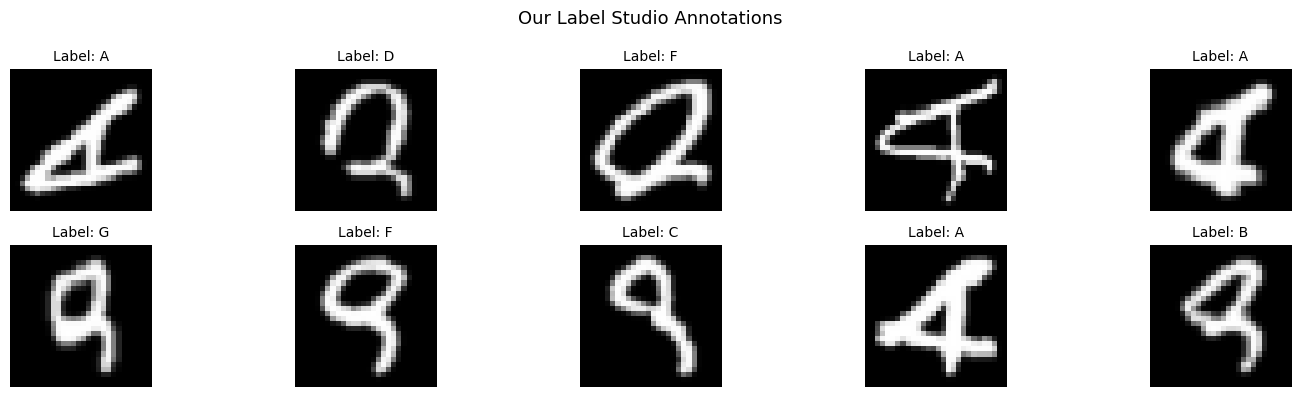

In [ ]:
plt.figure(figsize=(15, 4))
for i in range(min(10, len(images))):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {our_labels[i]}", fontsize=10)
    plt.axis('off')
plt.suptitle("Our Label Studio Annotations", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
label_to_idx = {ch: i for i, ch in enumerate(sorted(set(our_labels)))}
idx_to_label = {i: ch for ch, i in label_to_idx.items()}

print(f"Classes annotated: {label_to_idx}")

class AnnotatedEMNISTDataset(Dataset):
    """PyTorch Dataset built from real Label Studio annotations."""

    def __init__(self, images, labels, label_to_idx):
        self.images = images
        self.labels = [label_to_idx[l] for l in labels]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], torch.tensor(self.labels[idx], dtype=torch.long)

dataset = AnnotatedEMNISTDataset(images, our_labels, label_to_idx)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

x, y = next(iter(loader))
print(f"Batch shape: {x.shape}")
print(f"Labels: {[idx_to_label[i.item()] for i in y]}")

Classes annotated: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
Batch shape: torch.Size([4, 1, 28, 28])
Labels: ['A', 'A', 'D', 'C']


In [ ]:
# check: how many of our annotations match the original EMNIST ground truth?
correct = 0
total = 0

for fname, our_label in parsed:
    clean_fname = fname.split("-", 1)[1]
    idx = filename_to_idx.get(clean_fname)
    if idx is not None:
        _, true_label = emnist.dataset[idx] if hasattr(emnist, 'dataset') else emnist[idx]
        true_char = chr(64 + true_label)
        if our_label == true_char:
            correct += 1
        total += 1

print(f"Our annotations vs EMNIST ground truth: {correct}/{total} match")
print(f"Inter-annotator agreement proxy: {correct/total*100:.1f}%")
print()
print("Note: mismatches are expected — EMNIST labels are the")
print("original writer's intent, our labels are what WE see.")
print("This is exactly why annotation quality matters in real pipelines.")


Our annotations vs EMNIST ground truth: 6/18 match
Inter-annotator agreement proxy: 33.3%

Note: mismatches are expected — EMNIST labels are the
original writer's intent, our labels are what WE see.
This is exactly why annotation quality matters in real pipelines.



# FSDL Lab 6 Recap — Data Annotation & Dataset Preprocessing

## What We Did
Went through the full data annotation pipeline:
raw images → Label Studio annotation → JSON export → PyTorch Dataset

## The Process
1. Generated 20 EMNIST letter images and saved them as PNGs
2. Spun up Label Studio locally (localhost:8080)
3. Created a project with image classification interface (A-J labels)
4. Manually annotated all 20 images — selected the letter we saw
5. Exported annotations as JSON
6. Wrote a parser to load the JSON into (image, label) pairs
7. Built a custom PyTorch Dataset from the annotations
8. Compared our annotations against EMNIST ground truth

## Key Concepts Practiced
- Label Studio setup and annotation workflow
- JSON annotation export parsing
- Custom PyTorch Dataset from real annotated data
- Annotation quality — our labels vs ground truth

## Why Annotation Matters
The model is only as good as its labels. Ambiguous handwriting
means even human annotators disagree — this is called inter-annotator
disagreement and it sets the upper bound on model accuracy.
In production, multiple annotators label the same image and
majority vote is used to get cleaner labels.